In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings
warnings.filterwarnings('ignore')


In [3]:
df = pd.read_csv("forbes_richman.csv", encoding="latin1") # data contains european characters and csv wasnot stored in utf-8 format..it was in another format
df.head()

,Rank,Name,Net Worth,Age,Country,Source,Industry
0,1.0,Elon Musk,$219 B,50.0,United States,"Tesla, SpaceX",Automotive
1,2.0,Jeff Bezos,$171 B,58.0,United States,Amazon,Technology
2,3.0,Bernard Arnault & family,$158 B,73.0,France,LVMH,Fashion & Retail
3,4.0,Bill Gates,$129 B,66.0,United States,Microsoft,Technology
4,5.0,Warren Buffett,$118 B,91.0,United States,Berkshire Hathaway,Finance & Investments


In [4]:
df.shape

(2632, 7)

In [5]:
df.dtypes


Rank         float64
Name          object
Net Worth     object
Age          float64
Country       object
Source        object
Industry      object
dtype: object

In [6]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)

Index(['rank', 'name', 'net_worth', 'age', 'country', 'source', 'industry'], dtype='object')


In [7]:
df.rename(columns={'Net Worth': 'networth'}, inplace=True)

In [8]:
df.head(3)

,rank,name,net_worth,age,country,source,industry
0,1.0,Elon Musk,$219 B,50.0,United States,"Tesla, SpaceX",Automotive
1,2.0,Jeff Bezos,$171 B,58.0,United States,Amazon,Technology
2,3.0,Bernard Arnault & family,$158 B,73.0,France,LVMH,Fashion & Retail


In [9]:
print(df['net_worth'].isna().sum())
print(df['net_worth'].unique())

123
['$219 B' '$171 B' '$158 B' '$129 B' '$118 B' '$111 B' '$107 B' '$106 B'
 '$91.4 B' '$90.7 B' '$90 B' '$82 B' '$74.8 B' '$67.3 B' '$66.2 B'
 '$65.7 B' '$65.3 B' '$65 B' '$60 B' '$59.6 B' '$55.1 B' '$50 B' '$49.2 B'
 '$47.3 B' '$44.8 B' '$43.6 B' '$41.4 B' '$40.4 B' '$37.3 B' '$37.2 B'
 '$36.8 B' '$36.2 B' '$34.8 B' '$32.6 B' '$32.5 B' '$31.7 B' '$31.2 B'
 '$30.8 B' '$30.2 B' '$28.7 B' '$28.6 B' '$28.3 B' '$27.5 B' '$27.4 B'
 '$27.3 B' '$27.2 B' '$26.1 B' '$25.2 B' '$24.3 B' '$24.1 B' '$24 B'
 '$23.9 B' '$23.7 B' '$23.5 B' '$23.2 B' '$23.1 B' '$23 B' '$22.8 B'
 '$22.3 B' '$22.1 B' '$22 B' '$21.3 B' '$21.2 B' '$20.8 B' '$20.7 B'
 '$20.6 B' '$20.3 B' '$20.1 B' '$20 B' '$19.6 B' '$19.5 B' '$19 B'
 '$18.7 B' '$18.4 B' '$17.9 B' '$17.8 B' '$17.7 B' '$17.6 B' '$17.4 B'
 '$17.3 B' '$17.2 B' '$17.1 B' '$17 B' '$16.8 B' '$16.6 B' '$16.5 B'
 '$16.4 B' '$16.3 B' '$16.2 B' '$16.1 B' '$15.7 B' '$15.6 B' '$15.5 B'
 '$15.4 B' '$15.3 B' '$15.2 B' '$15.1 B' '$15 B' '$14.8 B' '$14.6 B'
 '$14.4 B' '$1

In [10]:
#convert to numeric
 #`[]` is a Regex thing — means "ANY of these": $ alone is just a character so regex=False, but [$B ] uses regex bracket syntax so regex=True is required! ✅
df['net_worth'] = pd.to_numeric(df['net_worth'].str.replace('[$B ]', '',regex=True), errors='coerce') # coerce menas if pandas find a value it cant convert in num..insted of crashing it puts nan 





In [11]:
df.describe() # we can see there can be extreme outliers but our goal is just to analyse the real data so we dont remove any outliers

,rank,net_worth,age
count,2509.000000,2509.000000,2430.000000
mean,1255.000000,4.759486,64.296708
std,724.430236,10.672003,13.357563
min,1.000000,1.000000,19.000000
25%,628.000000,1.500000,55.000000
50%,1255.000000,2.300000,64.000000
75%,1882.000000,4.300000,74.000000
max,2509.000000,219.000000,100.000000


In [12]:
after= df['net_worth'].isna().sum() # checking if coerce cahnges any of my values to nan...it didnit
after

123

In [13]:
print(df['net_worth'].unique())

[219.   171.   158.   129.   118.   111.   107.   106.    91.4   90.7
  90.    82.    74.8   67.3   66.2   65.7   65.3   65.    60.    59.6
  55.1   50.    49.2   47.3   44.8   43.6   41.4   40.4   37.3   37.2
  36.8   36.2   34.8   32.6   32.5   31.7   31.2   30.8   30.2   28.7
  28.6   28.3   27.5   27.4   27.3   27.2   26.1   25.2   24.3   24.1
  24.    23.9   23.7   23.5   23.2   23.1   23.    22.8   22.3   22.1
  22.    21.3   21.2   20.8   20.7   20.6   20.3   20.1   20.    19.6
  19.5   19.    18.7   18.4   17.9   17.8   17.7   17.6   17.4   17.3
  17.2   17.1   17.    16.8   16.6   16.5   16.4   16.3   16.2   16.1
  15.7   15.6   15.5   15.4   15.3   15.2   15.1   15.    14.8   14.6
  14.4   14.3   14.    13.9   13.65  13.6   13.5   13.2   12.9   12.8
  12.7   12.6   12.5   12.4   12.2   12.1   12.    11.9   11.8   11.7
  11.6   11.5   11.4   11.3   11.1   11.    10.9   10.7   10.6   10.5
  10.4   10.3   10.     9.9    9.8    9.7    9.5    9.4    9.3    9.2
   9.1    9.     8.9

In [14]:
print(df.isnull().sum()) # seem like null values in rows

rank         123
name         123
net_worth    123
age          202
country      123
source       123
industry     123
dtype: int64


In [15]:
# How many rows have nulls
print(df.isnull().any(axis=1).sum())



# Show rows where ALL values are null
print(df[df.isnull().all(axis=1)].shape[0])

202
123


In [16]:
#droping only if all rows are empty so use how=all not how=any
df.dropna(how='all',inplace=True)
df.shape

(2509, 7)

In [17]:
#lets check again if my column have emoty values remained
print(df.isnull().sum())

rank          0
name          0
net_worth     0
age          79
country       0
source        0
industry      0
dtype: int64


In [18]:
#lets cahnge how many percentage of age data is missing
#print(f"{(df['age'].isnull().sum() / len(df) * 100).round(2)}%")

print(f"{df['age'].isnull().mean() * 100: .2f}%") 

 3.15%



f means "hey python! i am going to mix TEXT and CODE together!
.2f is a prt of format how many numbers to put after decimal
mean is used cause mean= SUM of all values / total count
values are 1s and 0s

SUM of all values  =  sum of 1s and 0s
                   =  just COUNT of 1s
                      (because 0s add nothing!)

mean = count of 1s (nulls) / total rows

GroupBy = "put similar things together
           then calculate something!"

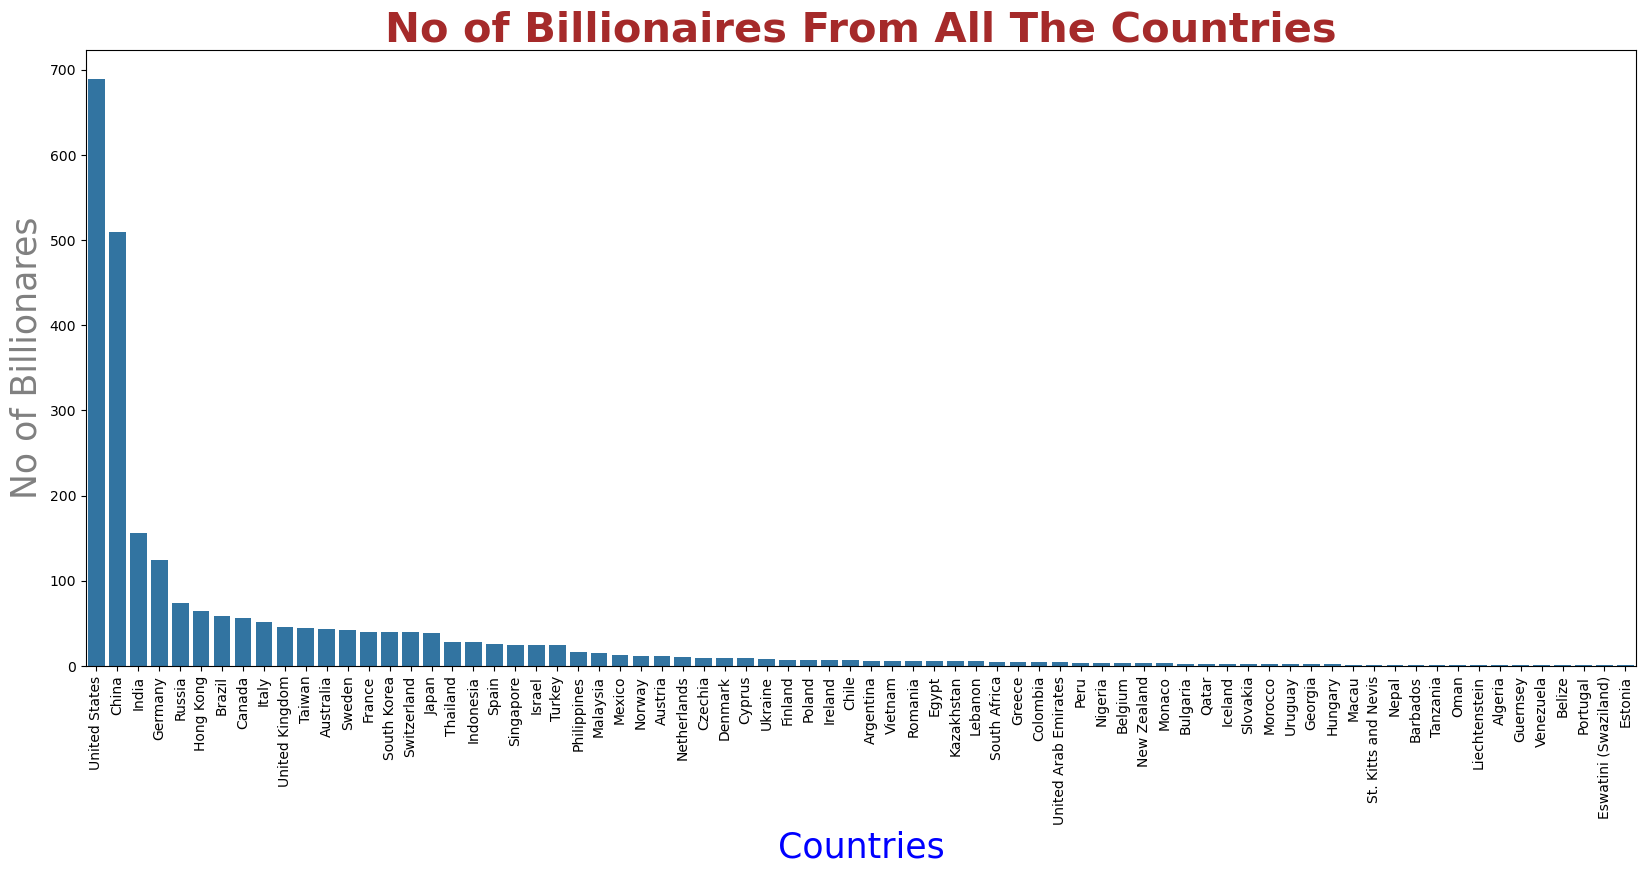

In [19]:
#data visualization
plt.figure(figsize=(20,8))
sns.countplot( data=df, x="country",order=df["country"].value_counts().index) # we are making highest count of billonare to lowest in order and index just print left part of it and right is ignored. value count gives eg. (germany 647)
plt.xticks(rotation=90)
plt.ylabel("No of Billionares",fontsize=25, color='gray')
plt.xlabel("Countries", fontsize=25,color='blue')

plt.title("No of Billionaires From All The Countries",fontsize=30,weight='bold',color='brown')
plt.show()


1. df['Country'] alone gives 2386 repeated unsorted rows — value_counts().index gives unique country names sorted by frequency — order parameter needs unique sorted names not repeated values
2. sns.countplot(data=df, x="country",order=df["country"].value_counts().index[:10]) means top 10
2. use .values instead of index if you want to count values.
3. countplot automatically counts how many times each x value appears and puts that count on y axis — it is literally built for counting so you never need to define y!


In [ ]:
print(df['country'].value_counts()['United States'])


689


In [21]:
top5 = df['country'].value_counts().head(5)
print(top5)

country
United States    689
China            509
India            156
Germany          124
Russia            74
Name: count, dtype: int64


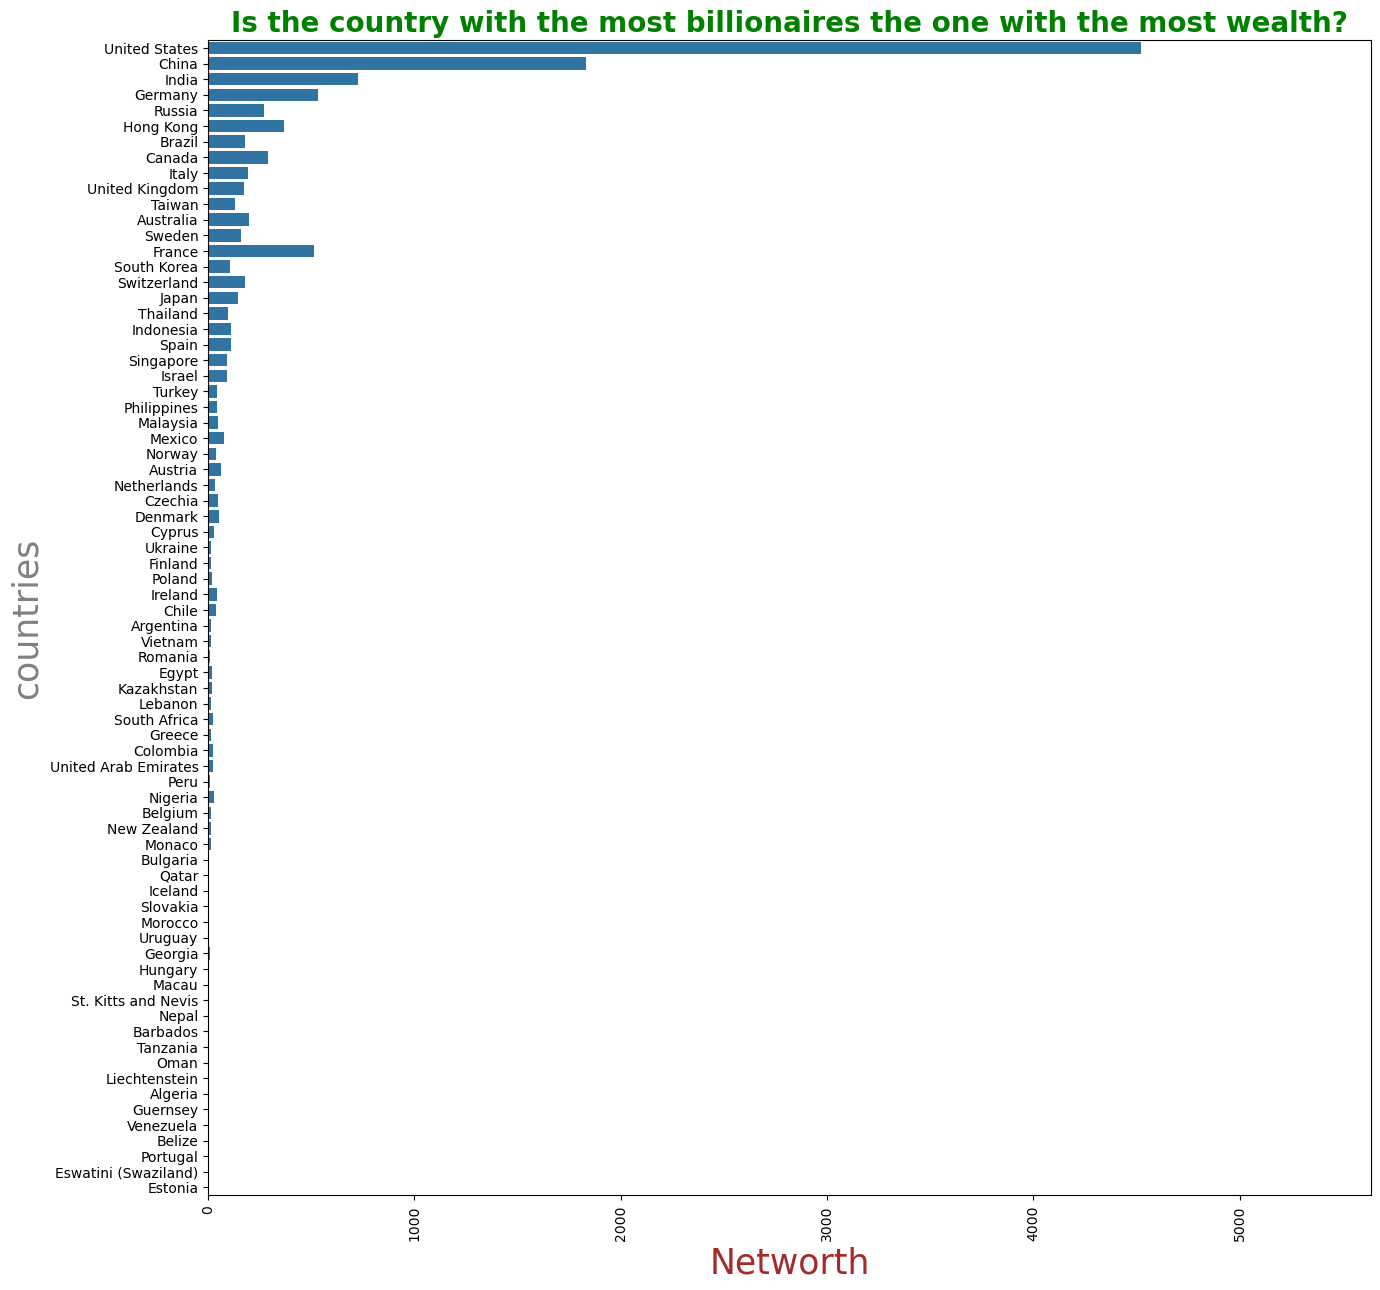

In [23]:
# networth vs country - to check does having more no of billionares means more networth...in some csase it maynot.

plt.figure(figsize=(15,15))
sns.barplot( data=df, x="net_worth",y="country",order=df["country"].value_counts().index,estimator=sum,errwidth=0)
plt.xticks(rotation=90)
plt.ylabel("countries",fontsize=25, color="grey")
plt.xlabel("Networth",fontsize=25,color='brown')
plt.title("Is the country with the most billionaires the one with the most wealth?", fontsize=20,weight='bold',color='green')
plt.show()

reason to use barplot

countplot  =  counting PEOPLE in each country  not what we want!
barplot  =  counting their MONEY in each country exactly what we want!, barplot can add the do estimator like add,sub,mean in the columns of data

conclusion- us is far away and the number of billionare were also high 

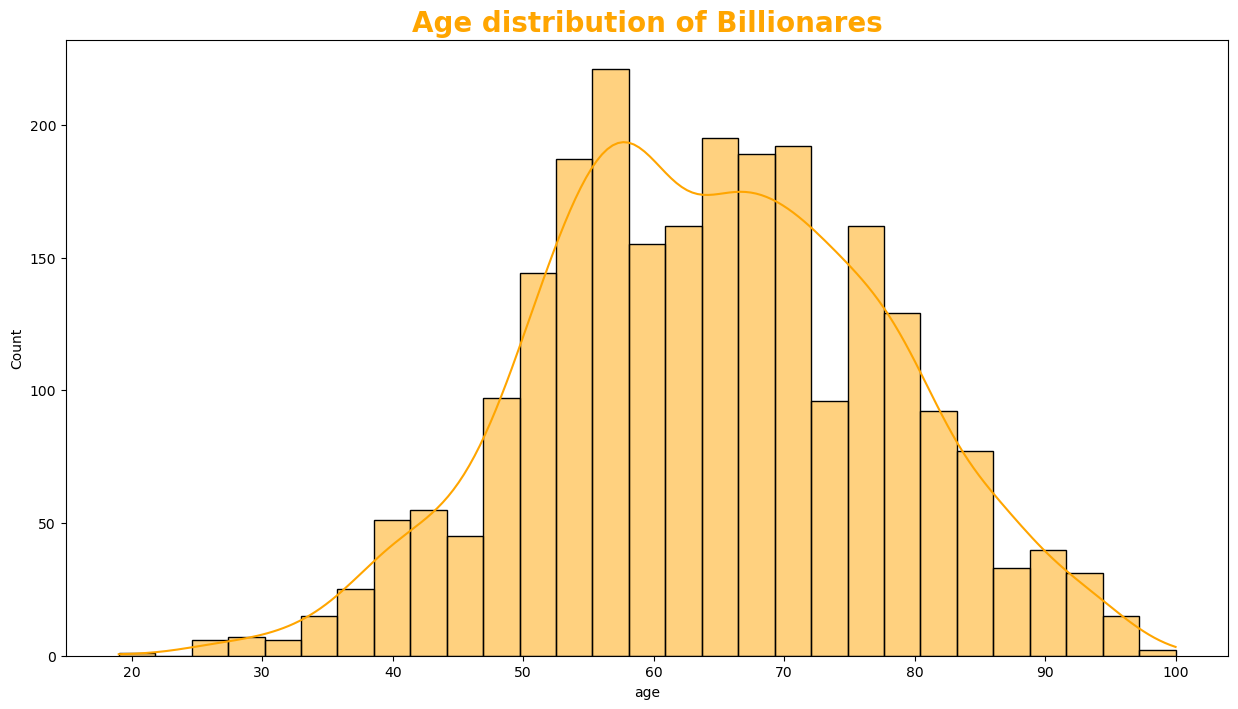

In [25]:
# age distibution

plt.figure(figsize=(15,8))
sns.histplot(data=df,x="age",color='orange',kde=True)
plt.title("Age distribution of Billionares",fontsize=20,color='orange',weight='bold')
plt.show()

In [ ]:
df[df['age'] == df['age'].min()]
#df.: df.loc[df.age==df.age.min()] 
'''df.age.min()        → finds minimum age
                      19.0

df.age == 19.0      → checks each row
                      True if age is 19
                      False if not

df.loc[True rows]   → returns only rows
                      where age is 19!'''

,rank,name,net_worth,age,country,source,industry
1230,1231.0,Kevin David Lehmann,2.4,19.0,Germany,drugstores,Fashion & Retail


In [32]:
#youngest billionare

df[df['age'] == df['age'].min()]['name']

1230    Kevin David Lehmann
Name: name, dtype: object

In [ ]:
# oldest billionare
print(df.age==df.age.max() )
'''df.age.max()
# just gives → 100.0
# single value, thats it!

df.age == 100.0
# goes through EVERY row and asks...
# "is this person's age 100.0?"

Row 1  → 50  == 100?  → False
Row 2  → 58  == 100?  → False
Row 3  → 73  == 100?  → False
Row 4  → 100 == 100?  → True  ✅
Row 5  → 91  == 100?  → False'''


0       False
1       False
2       False
3       False
4       False
        ...  
2504    False
2505    False
2506    False
2507    False
2508    False
Name: age, Length: 2509, dtype: bool


In [ ]:
df.loc[df.age==df.age.max()] # loc tells pandas for exact row

,rank,name,net_worth,age,country,source,industry
1575,1576.0,George Joseph,1.8,100.0,United States,insurance,Finance & Investments


In [ ]:
# age group 
'''create temporary variable
age_group = pd.cut(df['age'], bins=[18,30,50,70,100],
            include_lowest=True,
            labels=['18-30','30-50','50-70','70+'])

# use it for analysis
print(age_group.value_counts())

# after analysis its gone!
# df is unchangecd'''



<Axes: xlabel='age', ylabel='count'>

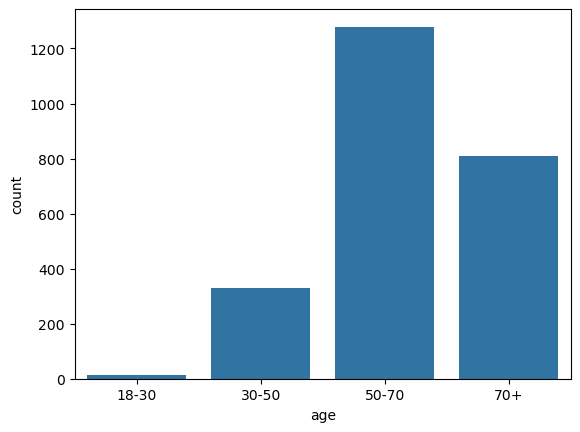

In [ ]:
sns.countplot(x=pd.cut(df['age'],    #pd.cut takes a NUMERICAL column and divides it into GROUPS
              bins=[18,30,50,70,100],
              labels=['18-30','30-50','50-70','70+']))

pd.cut(
    df['Age'],                    # column to cut
    bins=[18, 30, 50, 70, 100],  # where to cut
    include_lowest=True,          # include 18
    labels=['18-30','30-50',
            '50-70','70+']        # name each group

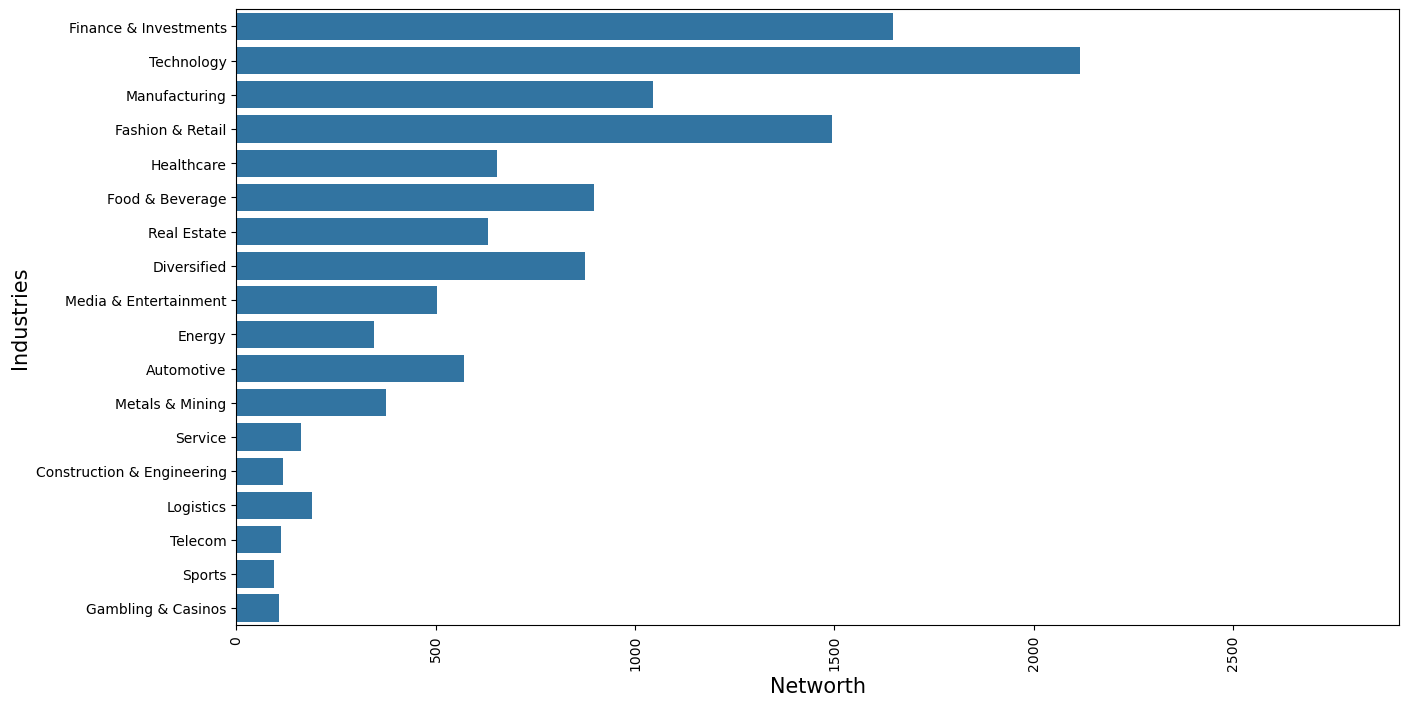

In [46]:
#. Now let’s have a look at the top domains with the most number of billionaires:
#to pick that we need to pick industry and networth column
plt.figure(figsize=(15,8))
sns.barplot(data=df, 
            x = "net_worth", y = "industry",
            order = df['industry'].value_counts().index, estimator = sum , errwidth = 0)
plt.xticks(rotation=90)
plt.xlabel("Networth", fontsize=15)
plt.ylabel("Industries", fontsize=15)
plt.show()

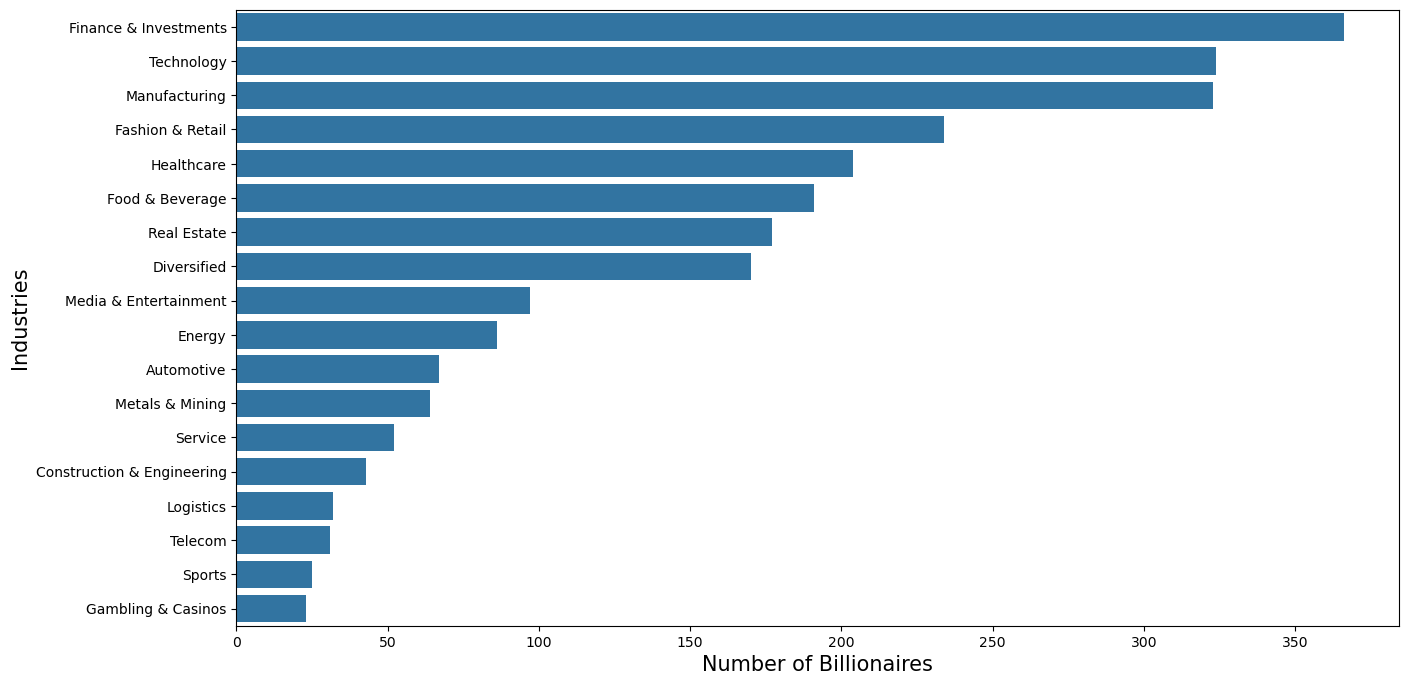

In [42]:
# first pick which industry is mostly picked to understand the differece in count and box plot
plt.figure(figsize=(15,8))
sns.countplot(
    data=df,
    y='industry',
    order=df['industry'].value_counts().index
)
plt.xlabel("Number of Billionaires", fontsize=15)
plt.ylabel("Industries", fontsize=15)
plt.show()

even more people invest in industry of finance and investment ..the net worth of people who invest in technology is higher.

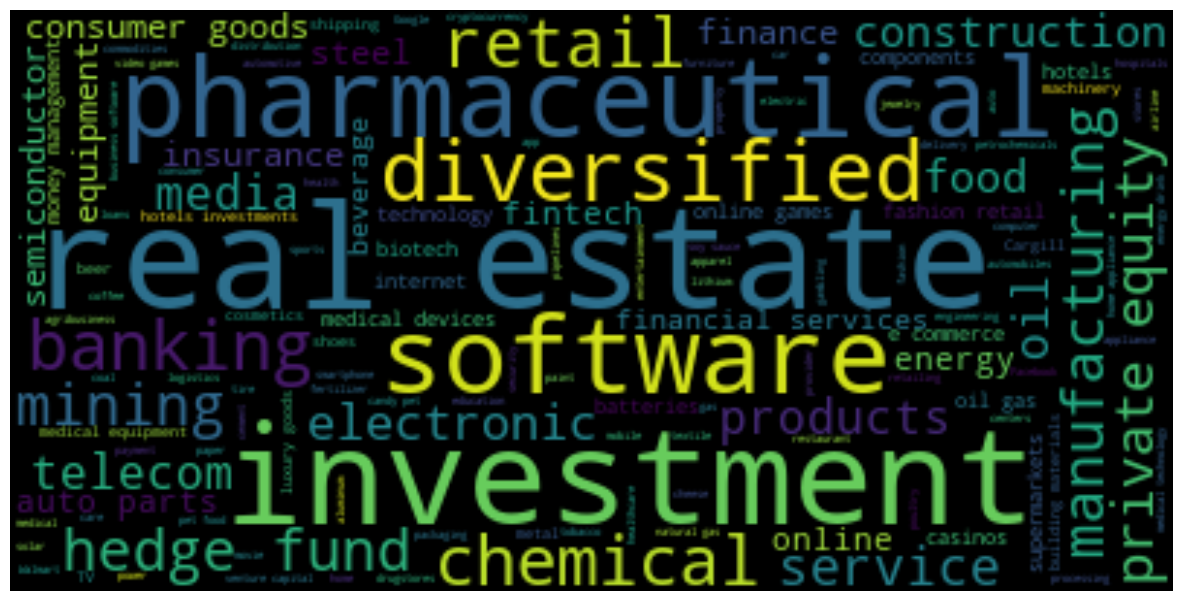

In [ ]:
#source of billionares
stopwords=set(STOPWORDS) # buildin stopwords is cahnged to set caused it fast to search
text= " ".join(i for i in df.source)# goes  through EVERY row in source column andjoins them into ONE big string!

plt.figure(figsize=(15,10))
wordcloud= WordCloud(
    stopwords=stopwords,
    max_words=200,
    max_font_size=50,
   random_state=50 #means every time you run this words appear in SAME position! makes it reproducible

).generate(text) #acually CREATES the wordcloud from our big text string
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')# removes x and y axis
plt.show()

list= dictionary without in read every page to find a word! so slow

Set  = dictionary WITH index go directly to the right page! so fast

Top 5 Billionaries from us

In [50]:
us_df= df[df['country']=='United States'].sort_values("net_worth",ascending=False).head()
us_df

,rank,name,net_worth,age,country,source,industry
0,1.0,Elon Musk,219.0,50.0,United States,"Tesla, SpaceX",Automotive
1,2.0,Jeff Bezos,171.0,58.0,United States,Amazon,Technology
3,4.0,Bill Gates,129.0,66.0,United States,Microsoft,Technology
4,5.0,Warren Buffett,118.0,91.0,United States,Berkshire Hathaway,Finance & Investments
5,6.0,Larry Page,111.0,49.0,United States,Google,Technology


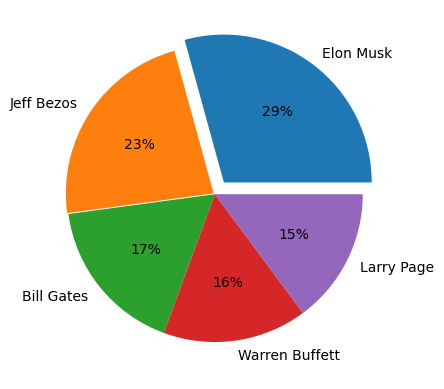

In [59]:
# plotting data on chart
plt.pie(us_df['net_worth'], labels=us_df['name'],
explode=  [0.1, 0.01, 0, 0, 0], autopct='%.0f%%')
# displaying chart
plt.show()


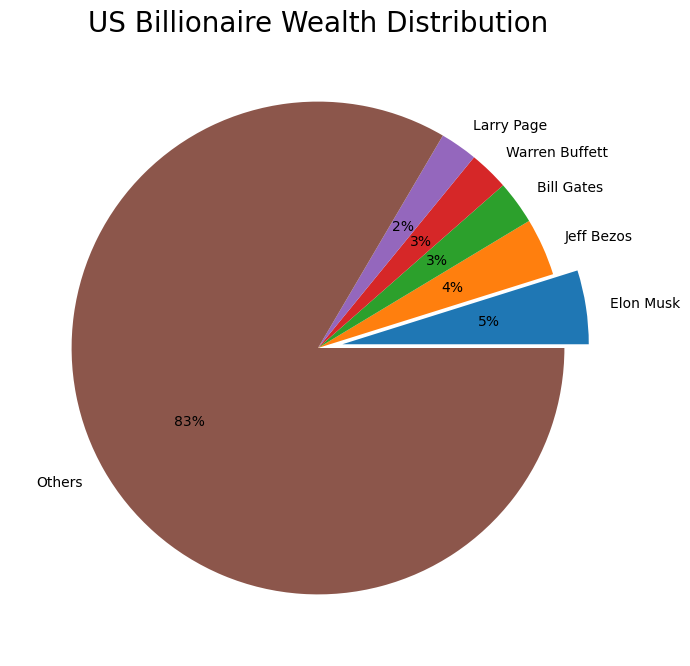

In [60]:
# Step 1 - filter USA billionaires
us_df = df[df['country'] == 'United States']

# Step 2 - get top 5 billionaires
top5 = us_df.nlargest(5, 'net_worth')

# Step 3 - calculate others
others_worth = us_df['net_worth'].sum() - top5['net_worth'].sum()

# Step 4 - create others row
others = pd.DataFrame({
    'name': ['Others'],
    'net_worth': [others_worth]
})

# Step 5 - combine top 5 with others
final_df = pd.concat([top5[['name', 'net_worth']], others])

# Step 6 - plot pie chart
plt.figure(figsize=(12,8))
plt.pie(
    final_df['net_worth'],
    labels=final_df['name'],
    autopct='%.0f%%',
    explode=[0.1, 0, 0, 0, 0, 0]  # highlight top 1
)
plt.title('US Billionaire Wealth Distribution', fontsize=20)
plt.show()

In [53]:
india=df.loc[df.country=='India'].sort_values("net_worth",ascending=False).head()
india

,rank,name,net_worth,age,country,source,industry
9,10.0,Mukesh Ambani,90.7,64.0,India,diversified,Diversified
10,11.0,Gautam Adani,90.0,59.0,India,"infrastructure, commodities",Diversified
43,44.0,Shiv Nadar,28.7,76.0,India,software services,Technology
53,54.0,Cyrus Poonawalla,24.3,80.0,India,vaccines,Healthcare
75,76.0,Radhakishan Damani,20.0,67.0,India,"retail, investments",Fashion & Retail


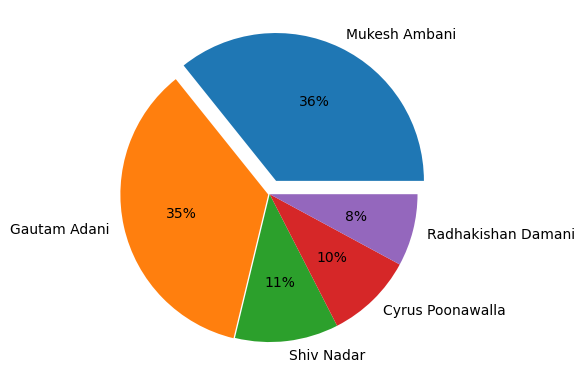

In [61]:
plt.pie(india['net_worth'], labels=india['name'],
explode=[0.1, 0.01, 0, 0, 0], autopct='%.0f%%')
# displaying chart
plt.show()

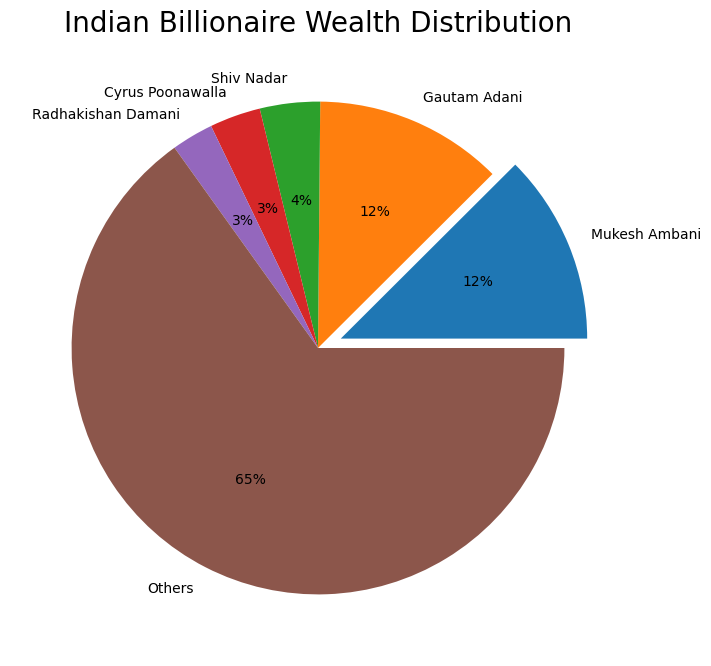

In [62]:
# Step 1 - filter indai billionaires
us_df = df[df['country'] == 'India']

# Step 2 - get top 5 billionaires
top5 = us_df.nlargest(5, 'net_worth')

# Step 3 - calculate others
others_worth = us_df['net_worth'].sum() - top5['net_worth'].sum()

# Step 4 - create others row
others = pd.DataFrame({
    'name': ['Others'],
    'net_worth': [others_worth]
})

# Step 5 - combine top 5 with others
final_df = pd.concat([top5[['name', 'net_worth']], others])

# Step 6 - plot pie chart
plt.figure(figsize=(12,8))
plt.pie(
    final_df['net_worth'],
    labels=final_df['name'],
    autopct='%.0f%%',
    explode=[0.1, 0, 0, 0, 0, 0]  # highlight top 1
)
plt.title('Indian Billionaire Wealth Distribution', fontsize=20)
plt.show()

In [55]:
china=df.loc[df.country=="China"].sort_values("net_worth",ascending=False).head()
china

,rank,name,net_worth,age,country,source,industry
15,16.0,Zhong Shanshan,65.7,67.0,China,"beverages, pharmaceuticals",Food & Beverage
23,24.0,Zhang Yiming,50.0,38.0,China,TikTok,Media & Entertainment
31,32.0,Ma Huateng,37.2,50.0,China,internet media,Technology
45,46.0,He Xiangjian,28.3,79.0,China,home appliances,Manufacturing
51,52.0,William Lei Ding,25.2,50.0,China,online games,Technology


In [69]:
def country_pie_chart(country_name):
    
    # check if country exists in dataframe
    if country_name not in df['country'].values:
        print(f"Sorry! '{country_name}' not found in dataset!")
        print("Available countries:")
        print(df['country'].unique())
        return
    
    # Step 1 - filter country billionaires
    country_df = df[df['country'] == country_name]
    
    # Step 2 - get top 5 billionaires
    top5 = country_df.nlargest(5, 'net_worth')
    
    # Step 3 - calculate others
    others_worth = country_df['net_worth'].sum() - top5['net_worth'].sum()
    
    # Step 4 - create others row
    others = pd.DataFrame({
        'name': ['Others'],
        'net_worth': [others_worth]
    })
    
    # Step 5 - combine top 5 with others
    final_df = pd.concat([top5[['name', 'net_worth']], others])
    
    # Step 6 - plot pie chart
    plt.figure(figsize=(12,8))
    plt.pie(
        final_df['net_worth'],
        labels=final_df['name'],
        autopct='%.0f%%',
        explode = [0.1] + [0] * (len(final_df) - 1)# Step 6 - dynamic explode based on length!
    )
    plt.title(f'{country_name} Billionaire Wealth Distribution', fontsize=20)
    plt.show()

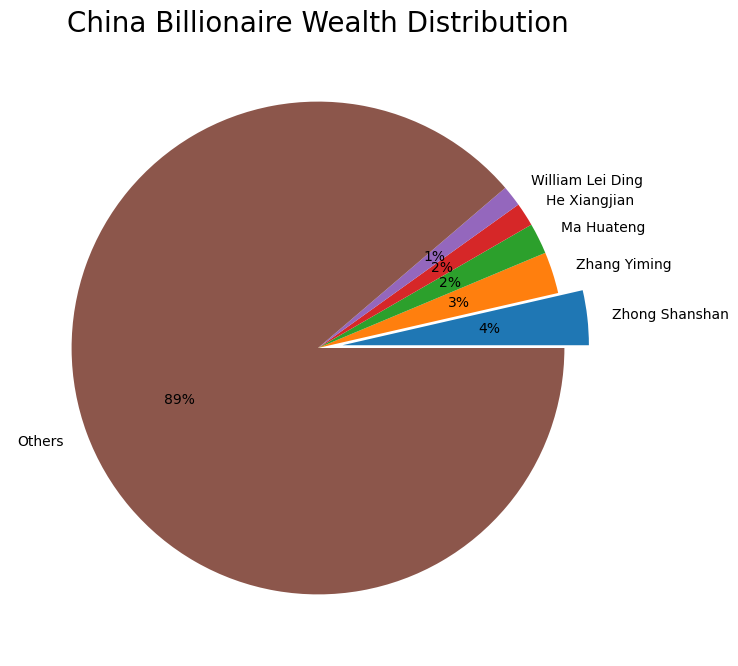

In [65]:
country_pie_chart("China")

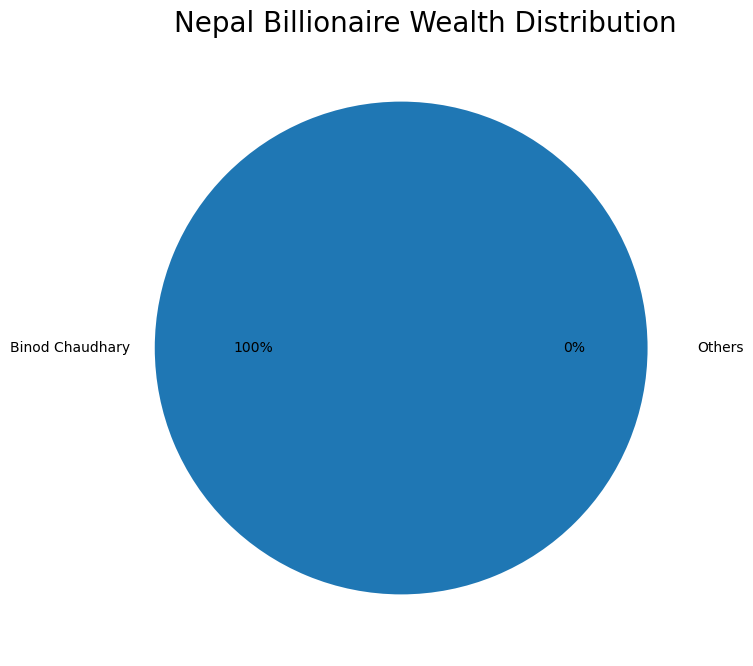

In [70]:
country_pie_chart("Nepal")

In [71]:
country_pie_chart("Bhutan")

Sorry! 'Bhutan' not found in dataset!
Available countries:
['United States' 'France' 'India' 'China' 'Canada' 'Spain' 'Hong Kong'
 'Germany' 'Italy' 'Mexico' 'Australia' 'Austria' 'Japan' 'Indonesia'
 'Switzerland' 'Chile' 'Russia' 'Singapore' 'Sweden' 'Czechia'
 'United Kingdom' 'Brazil' 'Netherlands' 'United Arab Emirates' 'Ireland'
 'Nigeria' 'Denmark' 'Thailand' 'Cyprus' 'Taiwan' 'Malaysia' 'Israel'
 'Monaco' 'Colombia' 'New Zealand' 'South Korea' 'Belgium' 'South Africa'
 'Philippines' 'Egypt' 'Greece' 'Norway' 'Poland' 'Eswatini (Swaziland)'
 'Peru' 'Algeria' 'Kazakhstan' 'Georgia' 'Turkey' 'Portugal' 'Finland'
 'Ukraine' 'Argentina' 'Belize' 'Venezuela' 'Vietnam' 'Lebanon' 'Romania'
 'Guernsey' 'Oman' 'Iceland' 'Liechtenstein' 'Qatar' 'Bulgaria' 'Morocco'
 'Macau' 'Barbados' 'Slovakia' 'St. Kitts and Nevis' 'Tanzania' 'Uruguay'
 'Nepal' 'Hungary' 'Estonia']
